Record: 100
Total samples: 1806 | Train: 1756 | Test(last 50s): 50
SARIMA order: (3, 1, 3), seasonal_order: (0, 0, 1, 12)
MAE  = 2.0553
MSE  = 5.8474
RMSE = 2.4181


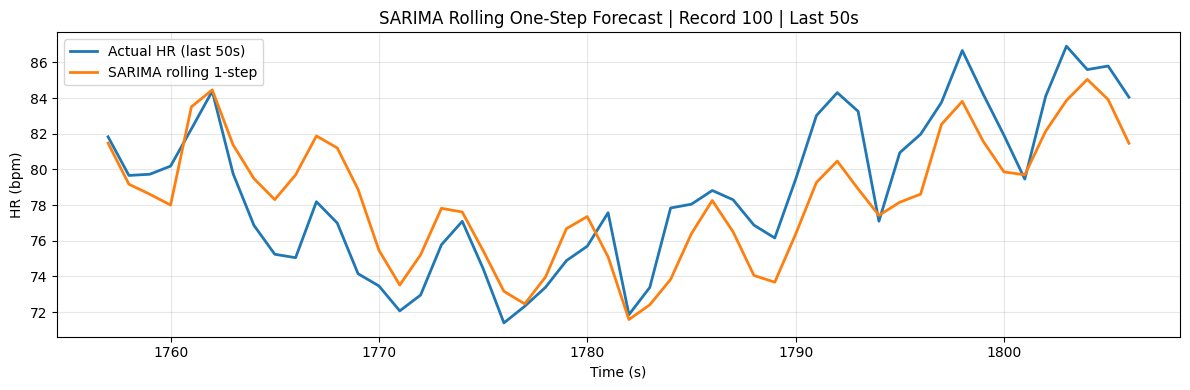

In [1]:
# CELL SARIMA-Rolling-50s — train full trước 50s cuối, rolling one-step forecast 50s cuối
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== Config =====
H = 50
record_id = "100"
order = (3, 1, 3)
seasonal_order = (0, 0, 1, 12)

# Nếu đã có HR_test từ các cell trước thì dùng lại, không thì tự tạo HR series từ annotation
if "HR_test" in globals() and record_id in HR_test:
    s = HR_test[record_id].dropna().astype(float)
else:
    pn_dir = "mitdb"
    ann = wfdb.rdann(record_id, "atr", pn_dir=pn_dir)
    hdr = wfdb.rdheader(record_id, pn_dir=pn_dir)
    fs = hdr.fs

    beat_symbols = set(["N","L","R","A","a","J","S","V","F","e","j","E","/","f","Q"])
    r_samples = np.array([x for x, sym in zip(ann.sample, ann.symbol) if sym in beat_symbols], dtype=int)

    rr = np.diff(r_samples) / fs
    t_hr = r_samples[1:] / fs
    hr = 60.0 / rr

    mask_phys = (rr >= 0.25) & (rr <= 2.5)
    s = pd.Series(hr[mask_phys], index=t_hr[mask_phys]).dropna().astype(float)

# Nếu index không đều theo giây, nội suy về 1 Hz cho forecast ổn định
if not np.issubdtype(np.asarray(s.index).dtype, np.number):
    s = pd.Series(s.values, index=np.arange(len(s)))

idx = np.arange(int(np.floor(s.index.min())), int(np.ceil(s.index.max())) + 1)
s_1hz = pd.Series(np.interp(idx, s.index.values.astype(float), s.values.astype(float)), index=idx)

if len(s_1hz) <= H + 30:
    raise ValueError(f"Series quá ngắn: len={len(s_1hz)} không đủ cho H={H}")

# ===== Split: train = toàn bộ trước 50s cuối, test = 50s cuối =====
train = s_1hz.iloc[:-H]
test = s_1hz.iloc[-H:]

print(f"Record: {record_id}")
print(f"Total samples: {len(s_1hz)} | Train: {len(train)} | Test(last {H}s): {len(test)}")
print(f"SARIMA order: {order}, seasonal_order: {seasonal_order}")

# ===== Rolling one-step with true update =====
model = SARIMAX(
    train.values,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res = model.fit(disp=False, maxiter=100)

preds = []
res_roll = res
for y_true in test.values:
    y_hat = float(res_roll.forecast(steps=1)[0])
    preds.append(y_hat)
    # cập nhật bằng giá trị thật vừa quan sát (rolling one-step)
    res_roll = res_roll.append([float(y_true)], refit=False)

pred = np.array(preds, dtype=float)

ae = mean_absolute_error(test.values, pred)
mse = mean_squared_error(test.values, pred)
rmse = float(np.sqrt(mse))

print(f"MAE  = {ae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")

# ===== Plot =====
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual HR (last 50s)", linewidth=2)
plt.plot(test.index, pred, label="SARIMA rolling 1-step", linewidth=2)
plt.title(f"SARIMA Rolling One-Step Forecast | Record {record_id} | Last {H}s")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Searching best (p,d,q) ...
  New best: order=(0, 0, 0), AIC=17842.62
  New best: order=(0, 0, 1), AIC=16055.02
  New best: order=(0, 0, 2), AIC=14926.50
  New best: order=(0, 0, 3), AIC=14057.90
  New best: order=(0, 1, 0), AIC=10526.70
  New best: order=(0, 1, 1), AIC=9489.74
  New best: order=(0, 1, 2), AIC=9487.37
  New best: order=(0, 1, 3), AIC=9452.92


c:\Users\MY PC\.pyenv\pyenv-win\versions\3.12.3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  New best: order=(2, 1, 2), AIC=9416.93
  New best: order=(2, 1, 3), AIC=9071.66


c:\Users\MY PC\.pyenv\pyenv-win\versions\3.12.3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  New best: order=(3, 1, 3), AIC=9014.57

Best pdq: (3, 1, 3) | seasonal_order: (0, 0, 1, 12) | AIC: 9014.57

Rerun with tuned pdq
MAE  = 2.0553
MSE  = 5.8474
RMSE = 2.4181


,p,d,q,AIC
0,3,1,3,9014.566964
1,2,1,3,9071.663110
2,3,1,2,9362.552973
3,2,1,2,9416.932276
4,0,1,3,9452.924321
5,1,1,3,9458.518275
6,3,1,1,9464.379565
7,1,0,3,9465.315475
8,2,1,1,9479.680711
9,1,1,2,9485.626074


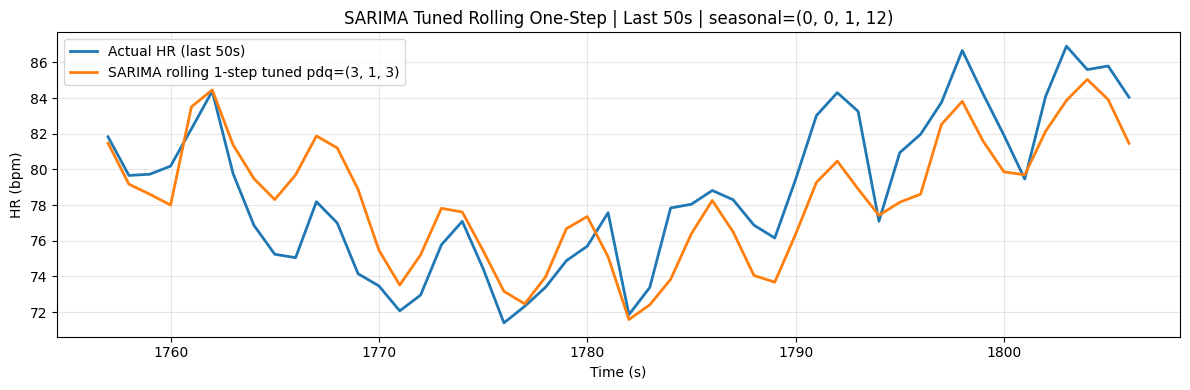

In [2]:
# CELL SARIMA-Tune-pdq-and-Rerun — tìm best (p,d,q) rồi chạy lại rolling one-step 50s cuối
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===== Input =====
H = 50
if "seasonal_order" not in globals():
    seasonal_order = (0, 0, 1, 12)

# Dùng train/test đã có từ cell trước; nếu chưa có thì tạo từ s_1hz
if "train" not in globals() or "test" not in globals():
    if "s_1hz" not in globals():
        raise ValueError("Chưa có dữ liệu. Hãy chạy cell SARIMA-Rolling-50s trước.")
    train = s_1hz.iloc[:-H]
    test = s_1hz.iloc[-H:]

# ===== Grid search best (p,d,q) by AIC on TRAIN =====
P_RANGE = [0, 1, 2, 3]
D_RANGE = [0, 1]
Q_RANGE = [0, 1, 2, 3]

best_aic = np.inf
best_order = None
results = []

print("Searching best (p,d,q) ...")
for p in P_RANGE:
    for d in D_RANGE:
        for q in Q_RANGE:
            try:
                m = SARIMAX(
                    train.values.astype(float),
                    order=(p, d, q),
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=80)

                aic = float(m.aic)
                results.append((p, d, q, aic))
                if np.isfinite(aic) and aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
                    print(f"  New best: order={best_order}, AIC={best_aic:.2f}")
            except Exception:
                continue

if best_order is None:
    raise RuntimeError("Không tìm được model SARIMA hợp lệ trong grid.")

print("\nBest pdq:", best_order, "| seasonal_order:", seasonal_order, "| AIC:", round(best_aic, 2))

# Lưu để dùng lại ở các cell sau
SARIMA_BEST_PDQ = best_order

# ===== Rerun rolling one-step forecast on last 50s =====
res0 = SARIMAX(
    train.values.astype(float),
    order=SARIMA_BEST_PDQ,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=100)

preds = []
res_roll = res0
for y_true in test.values.astype(float):
    y_hat = float(res_roll.forecast(steps=1)[0])
    preds.append(y_hat)
    res_roll = res_roll.append([y_true], refit=False)

pred = np.array(preds, dtype=float)
mae = mean_absolute_error(test.values, pred)
mse = mean_squared_error(test.values, pred)
rmse = float(np.sqrt(mse))

print("\nRerun with tuned pdq")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")

# bảng top 10 theo AIC
rank_df = pd.DataFrame(results, columns=["p", "d", "q", "AIC"]).sort_values("AIC").reset_index(drop=True)
display(rank_df.head(10))

# plot
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual HR (last 50s)", linewidth=2)
plt.plot(test.index, pred, label=f"SARIMA rolling 1-step tuned pdq={SARIMA_BEST_PDQ}", linewidth=2)
plt.title(f"SARIMA Tuned Rolling One-Step | Last {H}s | seasonal={seasonal_order}")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()